# Artificial Star Test with M2 and M34 Data

This notebook demonstrates how to perform artificial star tests on real FITS images to measure photometric completeness.

## Overview

The artificial star test workflow:
1. Load a real FITS image (M2 or M34)
2. Inject artificial stars at known positions and magnitudes
3. Run the photometry pipeline to detect sources
4. Calculate recovery fractions (completeness) as a function of magnitude
5. Fit a completeness model to the measured data

## Requirements

```python
pip install numpy scipy matplotlib astropy photutils
```

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import os
import warnings
warnings.filterwarnings('ignore')

# Import our pipeline utilities
from pipeline_utils import (
    load_fits_image,
    add_artificial_stars,
    run_artificial_star_test,
    print_ast_results
)

# Plotting style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 100

print("Ready to perform artificial star tests!")

Ready to perform artificial star tests!


## Step 1: Load Real FITS Image

We'll look for FITS files in the Data/ directory. If none are available, we'll create a realistic mock image for demonstration.

In [ ]:
# Check for available FITS files
data_dir = "./Data"
fits_files = []

if os.path.exists(data_dir):
    for root, dirs, files in os.walk(data_dir):
        for f in files:
            if f.endswith(".fits"): # or f.endswith(".fits.fz"):
                fits_files.append(os.path.join(root, f))

print(f"Found {len(fits_files)} FITS files in {data_dir}")

if len(fits_files) > 0:
    # Display available files
    print("\nAvailable FITS files:")
    for i, f in enumerate(fits_files):
        print(f"  {i}: {f}")
    
    # Use the first file by default
    selected_file = fits_files[0]
    print(f"\nUsing: {selected_file}")
    
    # Load the image
    try:
        data, header, wcs = load_fits_image(selected_file)
        print(f"✓ Loaded image: {data.shape}")
        print(f"  Exposure time: {header.get('EXPTIME', 'N/A')} s")
        print(f"  Filter: {header.get('FILTER', 'N/A')}")
        use_real_data = True
    except Exception as e:
        print(f"✗ Could not load FITS file: {e}")
        print("Will create mock data instead...")
        use_real_data = False
else:
    print("No FITS files found. Creating mock data for demonstration...")
    use_real_data = False

# Create mock data if needed
if not use_real_data:
    print("\nCreating realistic mock image...")
    np.random.seed(42)
    
    # Create background with gradient
    data = np.random.normal(1000, 50, size=(2000, 2000))
    y, x = np.ogrid[0:2000, 0:2000]
    gradient = 0.1 * x + 0.05 * y
    data += gradient
    
    # Add realistic number of background stars
    n_stars = 200
    star_x = np.random.uniform(100, 1900, n_stars)
    star_y = np.random.uniform(100, 1900, n_stars)
    star_positions = np.column_stack([star_x, star_y])
    star_mags = np.random.uniform(17, 23, n_stars)
    
    data = add_artificial_stars(data, star_positions, star_mags, fwhm=3.5)
    
    # Create mock header
    header = fits.Header()
    header["NAXIS"] = 2
    header["NAXIS1"] = 2000
    header["NAXIS2"] = 2000
    header["EXPTIME"] = 90.0
    header["GAIN"] = 1.4
    header["RDNOISE"] = 10.0
    header["FILTER"] = "gp"
    header["CRPIX1"] = 1000
    header["CRPIX2"] = 1000
    header["CRVAL1"] = 323.3625
    header["CRVAL2"] = -0.8231
    header["CD1_1"] = -0.000388
    header["CD1_2"] = 0.0
    header["CD2_1"] = 0.0
    header["CD2_2"] = 0.000388
    header["CTYPE1"] = "RA---TAN"
    header["CTYPE2"] = "DEC--TAN"
    wcs = WCS(header)
    
    print(f"✓ Created mock image: {data.shape}")
    print(f"  Added {n_stars} background stars")

# Display image statistics
print(f"\nImage statistics:")
print(f"  Mean: {np.mean(data):.1f}")
print(f"  Std: {np.std(data):.1f}")
print(f"  Min: {np.min(data):.1f}")
print(f"  Max: {np.max(data):.1f}")

Found 4 FITS files in ./Data/lco_data-20251126-4

Available FITS files:
  0: ./Data/lco_data-20251126-4/lsc0m476-sq34-20251119-0091-e00.fits
  1: ./Data/lco_data-20251126-4/lsc0m476-sq34-20251119-0090-e00.fits
  2: ./Data/lco_data-20251126-4/lsc0m476-sq34-20251119-0090-e91.fits
  3: ./Data/lco_data-20251126-4/lsc0m476-sq34-20251119-0091-e91.fits

Using: ./Data/lco_data-20251126-4/lsc0m476-sq34-20251119-0091-e00.fits
✓ Loaded image: (2400, 2400)
  Exposure time: 120.0 s
  Filter: gp

Image statistics:
  Mean: 675.6
  Std: 556.7
  Min: 519.0
  Max: 65534.0
✓ Loaded image: (2400, 2400)
  Exposure time: 120.0 s
  Filter: gp

Image statistics:
  Mean: 675.6
  Std: 556.7
  Min: 519.0
  Max: 65534.0


## Step 2: Visualize the Image

Let's take a look at the image we'll be testing.

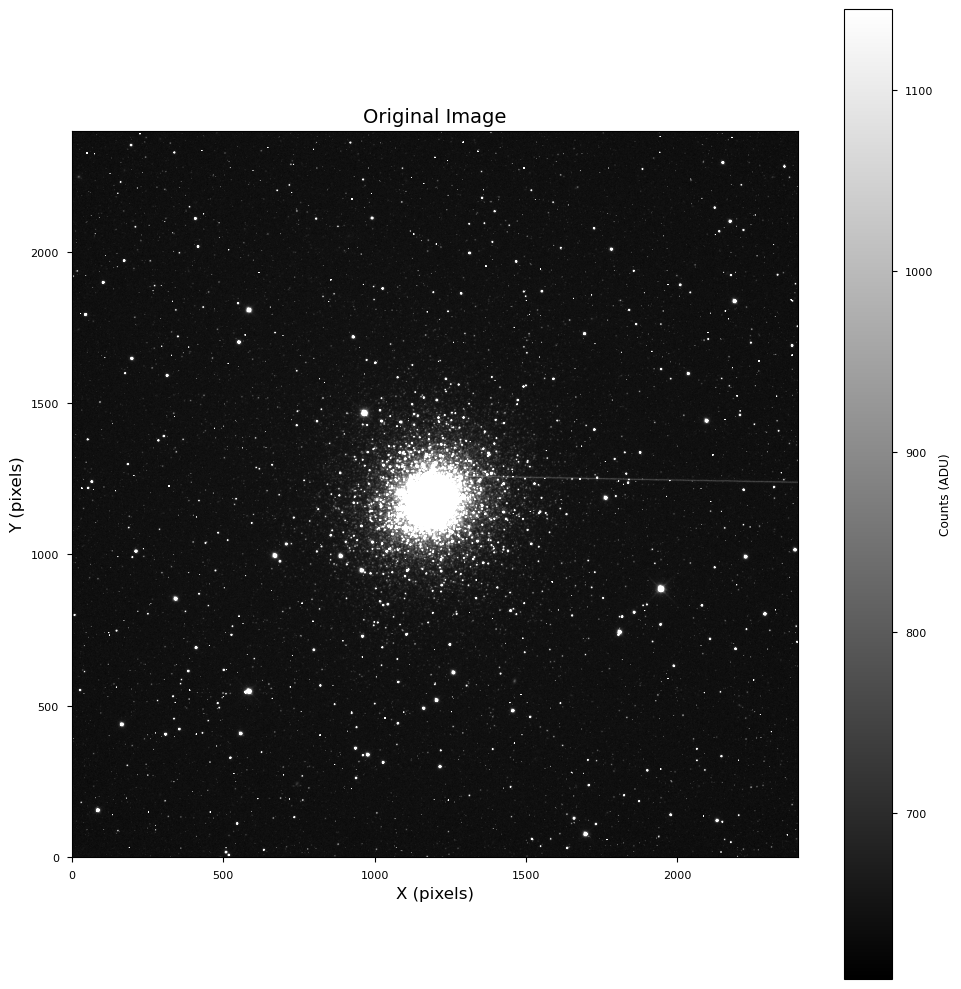

In [72]:
# Plot the image
fig, ax = plt.subplots(figsize=(10, 10))

# Use percentile-based scaling for better visualization
vmin, vmax = np.percentile(data, [1, 99])

im = ax.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
ax.set_xlabel('X (pixels)', fontsize=12)
ax.set_ylabel('Y (pixels)', fontsize=12)
ax.set_title('Original Image', fontsize=14)
plt.colorbar(im, ax=ax, label='Counts (ADU)')
plt.tight_layout()
plt.show()

## Step 3: Run Artificial Star Test

Now we'll inject artificial stars across a range of magnitudes and measure how many we can recover.

In [65]:
# Define test parameters
mag_bins = np.arange(14.0, 23.0, 0.5)  # Test from mag 14 to 23
n_stars_per_bin = 100  # Add 100 stars at each magnitude

# Get FWHM from header or use default
fwhm = header.get('L1FWHM', 3.5)  # pixels

# ← CHANGED: Use header zeropoint if available
zeropoint = header.get('L1ZP', 21.6)  # Read from FITS header

print("Artificial Star Test Configuration:")
print("=" * 50)
print(f"Magnitude range: {mag_bins.min():.1f} to {mag_bins.max():.1f}")
print(f"Magnitude bins: {len(mag_bins)}")
print(f"Stars per bin: {n_stars_per_bin}")
print(f"Total stars to inject: {len(mag_bins) * n_stars_per_bin}")
print(f"PSF FWHM: {fwhm:.1f} pixels")
print(f"Zeropoint: {zeropoint:.2f} mag")  # ← ADDED
print("=" * 50)

# Run the test (this may take a minute or two)
print("\nRunning artificial star test...")
print("This may take 1-2 minutes depending on image size.\n")

results = run_artificial_star_test(
    data=data,
    header=header,
    wcs=wcs,
    magnitude_bins=mag_bins,
    n_stars_per_bin=n_stars_per_bin,
    fwhm=fwhm,
    zeropoint=zeropoint,  # ← Use header value
    match_radius=2.0
)

# Display results
print_ast_results(results)

# Summary statistics
total_injected = np.sum(results['n_added'])
total_recovered = np.sum(results['n_recovered'])
overall_completeness = total_recovered / total_injected

print(f"\nOverall Statistics:")
print(f"  Total injected: {total_injected}")
print(f"  Total recovered: {total_recovered}")
print(f"  Overall completeness: {overall_completeness:.3f}")

Artificial Star Test Configuration:
Magnitude range: 14.0 to 22.5
Magnitude bins: 18
Stars per bin: 100
Total stars to inject: 1800
PSF FWHM: 3.5 pixels
Zeropoint: 21.60 mag

Running artificial star test...
This may take 1-2 minutes depending on image size.


Artificial Star Test Results:
 Magnitude |    Added |  Recovered | Completeness |    Error
----------------------------------------------------------------------
     14.00 |      100 |         78 |        0.780 |    0.041
     14.50 |      100 |         34 |        0.340 |    0.047
     15.00 |      100 |         12 |        0.120 |    0.032
     15.50 |      100 |          9 |        0.090 |    0.029
     16.00 |      100 |          1 |        0.010 |    0.010
     16.50 |      100 |          2 |        0.020 |    0.014
     17.00 |      100 |          5 |        0.050 |    0.022
     17.50 |      100 |          4 |        0.040 |    0.020
     18.00 |      100 |          3 |        0.030 |    0.017
     18.50 |      100 |      

In [66]:
# DIAGNOSTIC: Check why bright stars aren't 100% recovered
mag_bins = results['magnitude_bins']
completeness = results['completeness']
n_added = results['n_added']
n_recovered = results['n_recovered']

# Find bright bins with incomplete recovery
bright_incomplete = (mag_bins < 15.5) & (completeness < 0.98)

if np.any(bright_incomplete):
    print("\n⚠ Bright stars not fully recovered:")
    for i in np.where(bright_incomplete)[0]:
        print(f"  mag={mag_bins[i]:.1f}: {n_recovered[i]}/{n_added[i]} recovered ({completeness[i]:.2%})")
    
    print("\nPossible causes:")
    print("  1. Stars landing too close to image edges")
    print("  2. Stars landing on top of real sources (confusion)")
    print("  3. Detection threshold too high (sharpness/roundness cuts)")
    
    # Check border size
    border = 50  # from run_artificial_star_test
    ny, nx = data.shape
    usable_area = (nx - 2*border) * (ny - 2*border)
    total_area = nx * ny
    print(f"\n  Border exclusion: {border}px → {100*usable_area/total_area:.1f}% usable area")

# Check faint-end false recoveries
faint_unexpected = (mag_bins > 20) & (completeness > 0.05)

if np.any(faint_unexpected):
    print("\n⚠ Unexpectedly high recovery at faint end:")
    for i in np.where(faint_unexpected)[0]:
        print(f"  mag={mag_bins[i]:.1f}: {completeness[i]:.2%}")
    print("  → Likely matching to noise/spurious detections")


⚠ Bright stars not fully recovered:
  mag=14.0: 78/100 recovered (78.00%)
  mag=14.5: 34/100 recovered (34.00%)
  mag=15.0: 12/100 recovered (12.00%)

Possible causes:
  1. Stars landing too close to image edges
  2. Stars landing on top of real sources (confusion)
  3. Detection threshold too high (sharpness/roundness cuts)

  Border exclusion: 50px → 91.8% usable area


## Step 4: Fit Completeness Model

We'll fit an error function model to the completeness data:

$$C(m) = \frac{1}{2}\left[1 + \text{erf}\left(\frac{m_{50} - m}{\sqrt{2}\sigma_{\text{comp}}}\right)\right]$$

where $m_{50}$ is the magnitude at 50% completeness and $\sigma_{\text{comp}}$ controls the steepness.

In [67]:
from scipy.special import erf
from scipy.optimize import minimize

# Define completeness model
def completeness_model(m, m50, sigma_comp):
    """Error function completeness model"""
    return 0.5 * (1 + erf((m50 - m) / (np.sqrt(2) * sigma_comp)))

# Negative log-likelihood for fitting
def negative_log_likelihood(theta, m_bins, N_add, N_rec):
    """Binomial log-likelihood for completeness model"""
    m50, sigma_comp = theta
    
    # Compute model completeness
    C = completeness_model(m_bins, m50, sigma_comp)
    C = np.clip(C, 1e-10, 1 - 1e-10)
    
    # Binomial log-likelihood
    log_L = np.sum(N_rec * np.log(C) + (N_add - N_rec) * np.log(1 - C))
    
    return -log_L

# Extract data
m_bins = results['magnitude_bins']
N_add = results['n_added']
N_rec = results['n_recovered']
C_obs = results['completeness']
C_err = results['completeness_err']

# Fix: Add floor to errors to prevent division by zero
# When C=0 or C=1, binomial error is zero, but we need a minimum for chi-squared
# Use Poisson approximation: err ~ sqrt(N_rec) / N_add for small N_rec
C_err_safe = np.copy(C_err)
zero_err_mask = C_err_safe < 1e-10

if np.any(zero_err_mask):
    # For bins with zero error, use Poisson estimate
    C_err_safe[zero_err_mask] = np.sqrt(N_rec[zero_err_mask] + 1) / N_add[zero_err_mask]
    print(f"⚠ Fixed {np.sum(zero_err_mask)} bins with zero error (C=0 or C=1)")

# Also add a small floor to all errors to ensure numerical stability
C_err_safe = np.maximum(C_err_safe, 0.001)

# Initial guess: m50 around middle of range, sigma ~ 1 mag
theta_init = [np.median(m_bins), 1.0]

# Fit the model
result_fit = minimize(
    negative_log_likelihood,
    theta_init,
    args=(m_bins, N_add, N_rec),
    method='Nelder-Mead'
)

m50_fit, sigma_fit = result_fit.x

# Calculate chi-squared goodness of fit using safe errors
C_model = completeness_model(m_bins, m50_fit, sigma_fit)
chi2 = np.sum(((C_obs - C_model) / C_err_safe)**2)
dof = len(m_bins) - 2  # degrees of freedom (N_points - N_parameters)
reduced_chi2 = chi2 / dof

print("Fitted Completeness Model:")
print("=" * 50)
print(f"m50 (50% completeness): {m50_fit:.2f} mag")
print(f"sigma_comp (width): {sigma_fit:.2f} mag")
print(f"Log-likelihood: {-result_fit.fun:.2f}")
print("\nGoodness of Fit:")
print(f"Chi-squared (χ²): {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"Reduced chi-squared (χ²/dof): {reduced_chi2:.2f}")
if reduced_chi2 < 1.5:
    print("  → Excellent fit!")
elif reduced_chi2 < 3.0:
    print("  → Good fit")
else:
    print("  → Poor fit - model may not capture data well")
print("=" * 50)

# Calculate some useful metrics
m90 = m50_fit + sigma_fit * np.sqrt(2) * 0.906  # 90% completeness
m10 = m50_fit - sigma_fit * np.sqrt(2) * 0.906  # 10% completeness

print(f"\nCompleteness Levels:")
print(f"  90% complete at: {m90:.2f} mag")
print(f"  50% complete at: {m50_fit:.2f} mag")
print(f"  10% complete at: {m10:.2f} mag")
print(f"  Transition width (90% to 10%): {m10 - m90:.2f} mag")


Fitted Completeness Model:
m50 (50% completeness): 12.58 mag
sigma_comp (width): 3.49 mag
Log-likelihood: -454.76

Goodness of Fit:
Chi-squared (χ²): 465.41
Degrees of freedom: 16
Reduced chi-squared (χ²/dof): 29.09
  → Poor fit - model may not capture data well

Completeness Levels:
  90% complete at: 17.05 mag
  50% complete at: 12.58 mag
  10% complete at: 8.11 mag
  Transition width (90% to 10%): -8.94 mag


## Step 5: Visualize Results

Plot the measured completeness and fitted model.

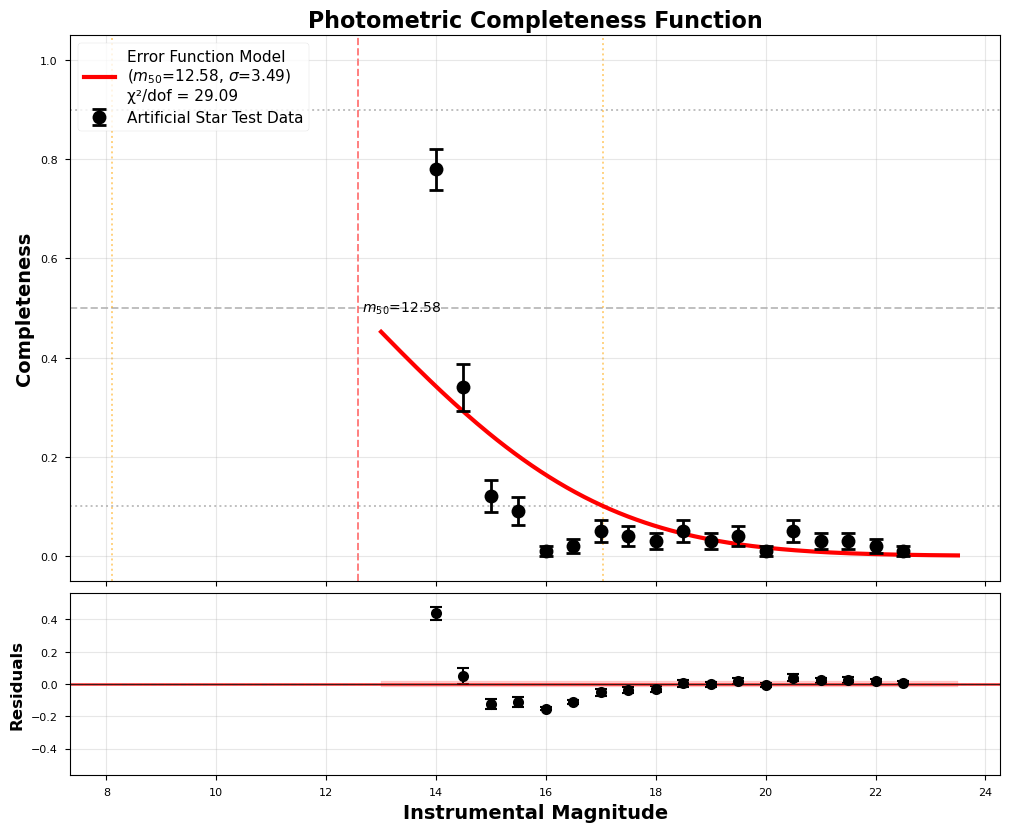

✓ Completeness analysis complete!


In [68]:
# Create completeness plot with residuals
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.1], hspace=0.05)
ax_main = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax_main)

# Main plot: Completeness vs Magnitude
# Use safe errors for plotting
ax_main.errorbar(m_bins, C_obs, yerr=C_err_safe,
                 fmt='o', color='black', markersize=10,
                 capsize=5, capthick=2, elinewidth=2,
                 label='Artificial Star Test Data', zorder=3)

# Plot fitted model
m_model = np.linspace(m_bins.min() - 1, m_bins.max() + 1, 200)
C_model_fine = completeness_model(m_model, m50_fit, sigma_fit)
C_model_points = completeness_model(m_bins, m50_fit, sigma_fit)

ax_main.plot(m_model, C_model_fine, 'r-', lw=3,
             label=f'Error Function Model\n($m_{{50}}$={m50_fit:.2f}, $\\sigma$={sigma_fit:.2f})\nχ²/dof = {reduced_chi2:.2f}',
             zorder=2)

# Mark key completeness levels
ax_main.axhline(0.5, color='gray', linestyle='--', alpha=0.5, zorder=1)
ax_main.axhline(0.9, color='gray', linestyle=':', alpha=0.5, zorder=1)
ax_main.axhline(0.1, color='gray', linestyle=':', alpha=0.5, zorder=1)

ax_main.axvline(m50_fit, color='red', linestyle='--', alpha=0.5, zorder=1)
ax_main.axvline(m90, color='orange', linestyle=':', alpha=0.5, zorder=1)
ax_main.axvline(m10, color='orange', linestyle=':', alpha=0.5, zorder=1)

# Formatting main plot
ax_main.set_ylabel('Completeness', fontsize=14, fontweight='bold')
ax_main.set_title('Photometric Completeness Function', fontsize=16, fontweight='bold')
ax_main.legend(fontsize=11, loc='upper left')
ax_main.grid(True, alpha=0.3)
ax_main.set_ylim(-0.05, 1.05)
ax_main.tick_params(labelbottom=False)

# Add text annotation for m50
ax_main.text(m50_fit, 0.5, f' $m_{{50}}$={m50_fit:.2f}',
             verticalalignment='center', fontsize=10)

# Residuals plot (use safe errors)
residuals = C_obs - C_model_points
ax_resid.errorbar(m_bins, residuals, yerr=C_err_safe,
                  fmt='o', color='black', markersize=8,
                  capsize=4, capthick=1.5, elinewidth=1.5)
ax_resid.axhline(0, color='red', linestyle='-', lw=2, alpha=0.7)
ax_resid.axhline(0, color='gray', linestyle='--', lw=1, alpha=0.5)

# Shade ±1σ region (use median error to avoid outliers)
median_err = np.median(C_err_safe)
ax_resid.fill_between(m_model, -median_err, median_err,
                       color='red', alpha=0.2, label='±1σ (median)')

# Formatting residuals plot
ax_resid.set_xlabel('Instrumental Magnitude', fontsize=14, fontweight='bold')
ax_resid.set_ylabel('Residuals', fontsize=12, fontweight='bold')
ax_resid.grid(True, alpha=0.3)
ax_resid.axhline(0, color='black', linestyle='-', lw=0.5)

# Set y-limits for residuals to be symmetric
resid_max = max(abs(ax_resid.get_ylim()[0]), abs(ax_resid.get_ylim()[1]))
ax_resid.set_ylim(-resid_max * 1.1, resid_max * 1.1)

plt.tight_layout()
plt.show()

print("✓ Completeness analysis complete!")


## Step 6: Save Results (Optional)

Save the completeness data and fitted parameters for use in other analyses.

In [69]:
# Save AST results to file
output_file = "completeness_ast_results.txt"

with open(output_file, 'w') as f:
    f.write("# Artificial Star Test Results\n")
    f.write("# Fitted Completeness Model: Error Function\n")
    f.write(f"# m50 = {m50_fit:.4f} mag\n")
    f.write(f"# sigma_comp = {sigma_fit:.4f} mag\n")
    f.write("#\n")
    f.write("# Magnitude  N_added  N_recovered  Completeness  Error\n")
    
    for i in range(len(m_bins)):
        f.write(f"{m_bins[i]:10.3f}  {N_add[i]:7d}  {N_rec[i]:11d}  "
                f"{C_obs[i]:12.4f}  {C_err[i]:7.4f}\n")

print(f"✓ Results saved to {output_file}")

# Also save the fitted model parameters in a simple format
params_file = "completeness_model_params.txt"
with open(params_file, 'w') as f:
    f.write(f"m50 {m50_fit:.4f}\n")
    f.write(f"sigma_comp {sigma_fit:.4f}\n")

print(f"✓ Model parameters saved to {params_file}")

✓ Results saved to completeness_ast_results.txt
✓ Model parameters saved to completeness_model_params.txt


## Conclusion

This notebook demonstrated how to:
1. Load real FITS images from M2 or M34
2. Perform artificial star tests to measure photometric completeness
3. Fit a completeness model to the data
4. Visualize and save the results

### Usage with Real Data

To use this with your M2 or M34 FITS images:
1. Place your FITS files in the `Data/` directory
2. Run the notebook - it will automatically detect and use the files
3. Adjust parameters as needed:
   - `mag_bins`: Range and spacing of magnitudes to test
   - `n_stars_per_bin`: Number of artificial stars per magnitude (more = better statistics but slower)
   - `match_radius`: Matching radius for recovery (should be ~FWHM)

### Interpreting Results

- **m50**: The magnitude at which 50% of stars are detected - a key metric for survey depth
- **sigma_comp**: Controls how sharply completeness drops - smaller values mean a steeper transition
- **Completeness curve**: Essential for correcting observed star counts to true populations

### Next Steps

Use the fitted completeness function to:
- Correct observed luminosity functions: $N_{\text{true}}(m) = N_{\text{obs}}(m) / C(m)$
- Weight cluster membership probabilities by detection efficiency
- Estimate uncertainty in faint-end measurements